# Autocall Phoenix: pricing and structuring walkthrough

This notebook reproduces the core workflow of an equity structuring desk on an
autocall Phoenix on the Euro Stoxx 50:

1. The product: term sheet and payoff mechanics
2. Pricing method: risk-neutral Monte Carlo on observation dates
3. Validation: hand calculations, limit cases and convergence
4. Results: par coupon sensitivities and product life statistics
5. Summary

All pricing logic lives in the `pricer` package (`src/pricer/`); this notebook only calls it.

In [61]:
import numpy as np
import matplotlib.pyplot as plt

from pricer.equity.models import simulate_gbm_paths
from pricer.equity.products import phoenix_cashflows
from pricer.equity.monte_carlo import price_phoenix
from pricer.equity.solver import phoenix_par_coupon

# Market and product parameters
S0, r, sigma = 100.0, 0.03, 0.20
TIMES = [1, 2, 3, 4, 5]   # annual observation dates (years)
COUPON = 0.08             # 8% per year, with memory
NOMINAL = 1000.0

## 1. The product

| Feature | Value |
|---|---|
| Underlying | Euro Stoxx 50 (initial level = 100%) |
| Nominal | 1,000 € |
| Maximum maturity | 5 years, annual observations |
| Autocall barrier | 100% |
| Coupon barrier | 70%, coupon of 8% p.a. with memory |
| Protection barrier | 60%, observed at maturity only |

At each observation date (years 1 to 4):

- Index ≥ 100%: early redemption at nominal + coupon (+ memorized coupons).
- 70% ≤ index < 100%: coupon paid (+ memorized coupons), the product continues.
- Index < 70%: no coupon, it is memorized.

At maturity (year 5): nominal + coupons if the index is ≥ 70%; nominal only
between 60% and 70%; below 60%, the client bears the full index loss (nominal × index performance).

In exchange for the conditional coupons, the client has in effect sold the bank a
down-and-in put at 60%.
The payoff depends on the whole path (early redemption, memory), so there is no simple
closed form and we price it by Monte Carlo.

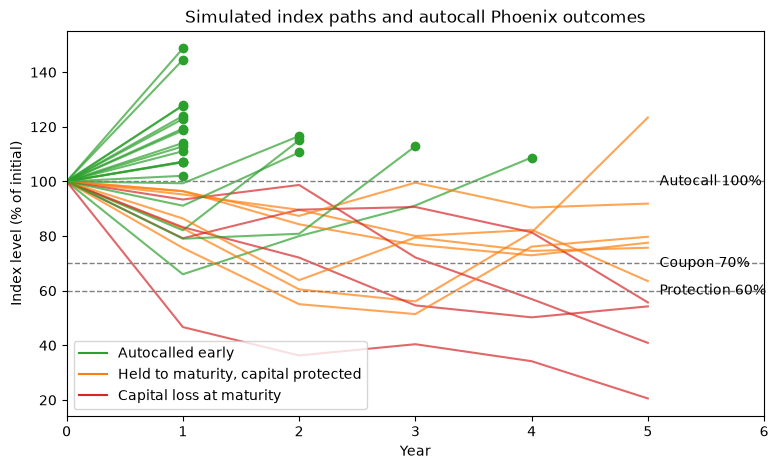

In [62]:
n_show = 30
paths = simulate_gbm_paths(S0, r, sigma, TIMES, n_paths=n_show, seed=23)
flows = phoenix_cashflows(paths, S0, COUPON)
last = flows[:, -1]

# Outcome of each path: autocalled, protected at maturity, or capital loss
colors = np.where(last == 0, "tab:green", np.where(last < 600, "tab:red", "tab:orange"))

# Date at which each product ends (first autocall date, or maturity)
called = paths[:, :-1] >= S0
end_date = np.where(called.any(axis=1), called.argmax(axis=1) + 1, 5) # Each path : date of first call if it was called, otherwise maturity (5)

full = np.column_stack([np.full(n_show, S0), paths])   # add the starting point S0 to paths

fig, ax = plt.subplots(figsize=(9, 5))
for path, end, color in zip(full, end_date, colors):
    ax.plot(range(end + 1), path[:end + 1], color=color, alpha=0.7)
    if end < 5:
        ax.plot(end, path[end], "o", color=color)

for level, label in [(100, "Autocall 100%"), (70, "Coupon 70%"), (60, "Protection 60%")]:
    ax.axhline(level, linestyle="--", color="gray", linewidth=1)
    ax.text(5.1, level, label, va="center")

# Empty lines, used only to build the legend
ax.plot([], [], color="tab:green", label="Autocalled early")
ax.plot([], [], color="tab:orange", label="Held to maturity, capital protected")
ax.plot([], [], color="tab:red", label="Capital loss at maturity")

ax.set_xlim(0, 6)
ax.set_xlabel("Year")
ax.set_ylabel("Index level (% of initial)")
ax.set_title("Simulated index paths and autocall Phoenix outcomes")
ax.legend(loc="lower left")
plt.show()

## 2. Pricing method

Under the risk-neutral measure, the index is simulated at the observation dates only,
one step at a time with independent shocks:

$$S_{t+\Delta t} = S_t \exp\Big[\big(r - \tfrac{\sigma^2}{2}\big)\Delta t + \sigma\sqrt{\Delta t}\,Z\Big],
\qquad Z \sim \mathcal{N}(0,1)$$

For each path, the cash flows are discounted at their own payment date, and the
fair value is the average over all paths (N):

$$V = \frac{1}{N}\sum_{i=1}^{N} \sum_{t} \text{CF}^{(i)}_t \, e^{-rt}$$

The par coupon is the coupon that makes the fair value equal to the nominal. It is
found with a root solver (`brentq`), using the same simulated paths for every trial
coupon (common random numbers), so that the value is a smooth function of the coupon.

In [63]:
value, se = price_phoenix(S0, r, sigma, TIMES, coupon=COUPON)
par = phoenix_par_coupon(S0, r, sigma, TIMES)
with_margin = phoenix_par_coupon(S0, r, sigma, TIMES, target=0.985 * NOMINAL)


print(f"Fair value with an 8% coupon: {value:.2f} ± {1.96 * se:.2f}€ (95% CI), for a nominal of {NOMINAL:.0f}€")
print(f"Par coupon (value = nominal):  {par:.2%}")
print(f"Coupon with a 1.5% margin:     {with_margin:.2%}")

Fair value with an 8% coupon: 1050.43 ± 0.99€ (95% CI), for a nominal of 1000€
Par coupon (value = nominal):  5.34%
Coupon with a 1.5% margin:     4.55%


With these market parameters, an 8% coupon is too generous: hedging
the product would cost the bank about 1,050€ for a note sold at 1,000€. The coupon
the bank can actually offer is the par coupon (about 5.3%), or about 4.6% once it keeps
a 1.5% margin on the nominal (a target value of 985€).

Real-life autocalls often show higher coupons because of effects this simple model leaves out:
dividends, the issuer's funding spread, or riskier underlyings
(single stocks, worst-of baskets). Section 4 shows how the main structuring levers move the coupon.

## 3. Validation

There is no closed form for this product, so the pricer is validated in three ways
(see `tests/`):

- Hand calculations: cash flows of term-sheet scenarios checked date by date.
- Limit cases where the product collapses to something with a known value:
  - never called, always protected: a zero-coupon bond worth $1000\,e^{-5r}$;
  - never called, never protected: the index itself, worth the nominal.
- Convergence: the Monte Carlo error shrinks as $1/\sqrt{N}$.

In [64]:
zc, _ = price_phoenix(S0, r, sigma, TIMES, coupon=0.0,
                      autocall_barrier=np.inf, protection_barrier=0.0)
idx, idx_se = price_phoenix(S0, r, sigma, TIMES, coupon=0.0,
                            autocall_barrier=np.inf, protection_barrier=np.inf)

print(f"Never called, always protected: {zc:8.2f}   vs zero-coupon bond {NOMINAL * np.exp(-r * 5):8.2f}")
print(f"Never called, never protected:  {idx:8.2f} ± {1.96 * idx_se:.2f}   vs nominal {NOMINAL:8.2f}")

Never called, always protected:   860.71   vs zero-coupon bond   860.71
Never called, never protected:    999.88 ± 2.92   vs nominal  1000.00


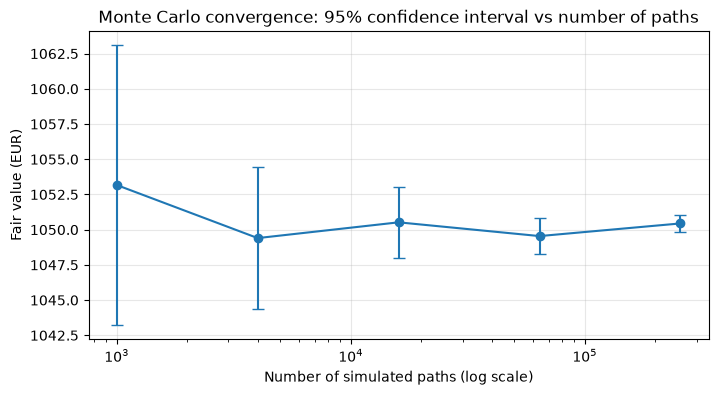

In [65]:
# Monte carlo convergence

n_list = [1_000, 4_000, 16_000, 64_000, 256_000]
results = [price_phoenix(S0, r, sigma, TIMES, coupon=COUPON, n_paths=n) for n in n_list]
values = np.array([v for v, _ in results])
errors = np.array([1.96 * s for _, s in results])

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(n_list, values, yerr=errors, fmt="o-", capsize=4)
ax.set_xscale("log")
ax.set_xlabel("Number of simulated paths (log scale)")
ax.set_ylabel("Fair value (EUR)")
ax.set_title("Monte Carlo convergence: 95% confidence interval vs number of paths")
ax.grid(True, alpha=0.3)
plt.show()

## 4. Results

### 4.1 Par coupon sensitivities

The par coupon is the structurer's main output: the maximum coupon the bank can offer
before taking any margin. Below, it is recomputed while moving one parameter at a time.

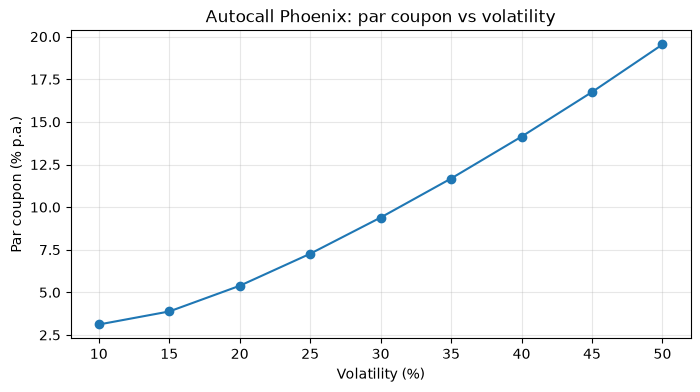

In [66]:
from pathlib import Path

DOCS = Path("../../docs/equity")       # README figures are saved here
DOCS.mkdir(exist_ok=True)

vols = np.arange(0.10, 0.51, 0.05)
par_vs_vol = [phoenix_par_coupon(S0, r, s, TIMES, n_paths=50_000) for s in vols]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(vols * 100, np.array(par_vs_vol) * 100, "o-")
ax.set_xlabel("Volatility (%)")
ax.set_ylabel("Par coupon (% p.a.)")
ax.set_title("Autocall Phoenix: par coupon vs volatility")
ax.grid(True, alpha=0.3)
fig.savefig(DOCS / "par_coupon_vs_vol.png", dpi=150, bbox_inches="tight")
plt.show()

Volatility is the dominant driver of the par coupon: it rises from about 3.1% at
σ = 10% to about 19.5% at σ = 50%, i.e. roughly 2.4 points of coupon for every 5 points of
volatility above 20%.

The client is short a down-and-in put at 60%. Higher volatility makes the index more likely
to end below the protection barrier, so this put is worth more, and the bank can pay more coupon
in exchange. This is why autocalls on single stocks (σ typically 25-40%, and up to 50% or more for
the most volatile names) offer much higher coupons than autocalls on an index (σ around 15-20%).

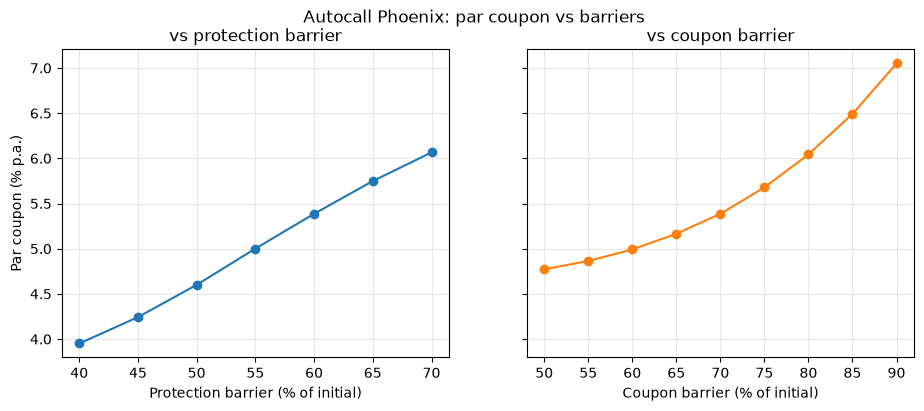

In [67]:
protection_levels = np.arange(0.40, 0.75, 0.05)
coupon_levels = np.arange(0.50, 0.95, 0.05)

par_vs_protection = [phoenix_par_coupon(S0, r, sigma, TIMES, n_paths=50_000, protection_barrier=b)
               for b in protection_levels]
par_vs_coupon = [phoenix_par_coupon(S0, r, sigma, TIMES, n_paths=50_000, coupon_barrier=b)
              for b in coupon_levels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharey=True) # sharey : same vertical axis

ax1.plot(protection_levels * 100, np.array(par_vs_protection) * 100, "o-")
ax1.set_xlabel("Protection barrier (% of initial)")
ax1.set_ylabel("Par coupon (% p.a.)")
ax1.set_title("vs protection barrier")
ax1.grid(True, alpha=0.3)

ax2.plot(coupon_levels * 100, np.array(par_vs_coupon) * 100, "o-", color="tab:orange")
ax2.set_xlabel("Coupon barrier (% of initial)")
ax2.set_title("vs coupon barrier")
ax2.grid(True, alpha=0.3)

fig.suptitle("Autocall Phoenix: par coupon vs barriers")
fig.savefig(DOCS / "par_coupon_vs_barriers.png", dpi=150, bbox_inches="tight")
plt.show()

Both barriers increase the par coupon, but through different mechanisms:

- Protection barrier (40% → 70%): the par coupon goes from about 4.0% to about 6.1%.
  A higher barrier means the client bears the index loss more often: they sell a more valuable
  put, which finances a higher coupon. The client pays for the higher coupon with more capital risk.
- Coupon barrier (50% → 90%): the par coupon goes from about 4.8% to about 7.1%, with an
  effect that accelerates as the barrier approaches 100%. Below 70%, few paths are both alive and
  that low at an observation date, so the barrier matters less. Near 90%, coupons become much less
  frequent, and each one can be larger. The capital risk is unchanged; what the client gives up
  is coupon certainty.

Because the two levers sell different risks, the choice depends on the client. For a client who
must protect their capital, raising the coupon barrier is preferable; for a client who wants
regular income, raising the protection barrier is.

Compared with volatility, the barriers have a moderate effect: moving the protection barrier by
30 points adds about 2 points of coupon, about as much as 5 points of volatility.

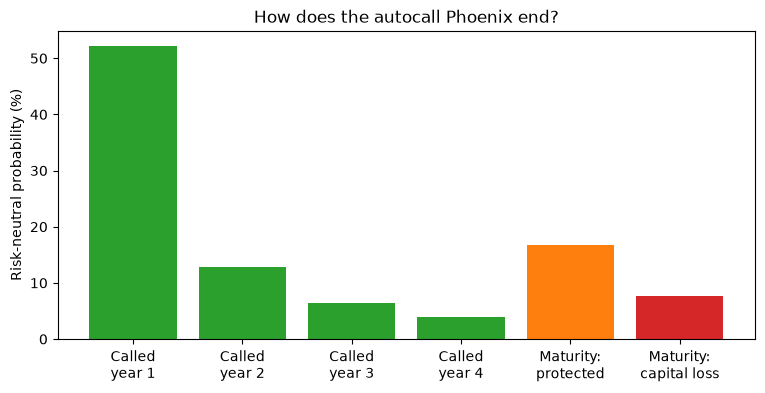

Expected life: 2.36 years (maximum 5)
Probability of capital loss: 7.7%
Average loss when it happens: 515€ per 1000€


In [68]:
paths = simulate_gbm_paths(S0, r, sigma, TIMES)
flows = phoenix_cashflows(paths, S0, COUPON)
last = flows[:, -1]

called = paths[:, :-1] >= S0
end_date = np.where(called.any(axis=1), called.argmax(axis=1) + 1, 5)
at_maturity = end_date == 5
loss = at_maturity & (last < NOMINAL)

labels = ["Called\nyear 1", "Called\nyear 2", "Called\nyear 3", "Called\nyear 4",
          "Maturity:\nprotected", "Maturity:\ncapital loss"]
probs = [(end_date == k).mean() for k in range(1, 5)] + [(at_maturity & ~loss).mean(), loss.mean()]
colors = ["tab:green"] * 4 + ["tab:orange", "tab:red"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(labels, np.array(probs) * 100, color=colors)
ax.set_ylabel("Risk-neutral probability (%)")
ax.set_title("How does the autocall Phoenix end?")
fig.savefig(DOCS / "product_life.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Expected life: {end_date.mean():.2f} years (maximum 5)")
print(f"Probability of capital loss: {loss.mean():.1%}")
print(f"Average loss when it happens: {(NOMINAL - last[loss]).mean():.0f}€ per {NOMINAL:.0f}€")

The product rarely lives five years:

- About 52% of paths are called after the first year. The condition is simply "the index is
  above its initial level in one year", the same event as a one-year at-the-money call
  ending in the money, with risk-neutral probability $N(d_2) \approx 52\%$.
- Calls become rarer in later years (about 13%, 6.5% and 4% in years 2 to 4): the paths that
  survive are those where the index has fallen, so they are further from the autocall barrier.
- The expected life is about 2.4 years, much shorter than the 5-year maximum maturity.
  Structurers watch the expected life as well as the maturity, because it drives how much
  each point of coupon costs and how long the bank has to hedge.

Capital losses are rare (7.7% of paths) but severe: 515€ per 1,000€ on average, i.e. about
half of the nominal. This is the cliff effect of the protection barrier: at maturity, an index at
60% returns the full nominal, while an index at 59% returns only 590€.

These are risk-neutral probabilities, used for pricing. Real-world probabilities differ (equities
earn a risk premium on average), but the orders of magnitude are informative.

## 5. Summary

- With σ = 20%, an 8% coupon is worth about 105% of the nominal. The par coupon is about 5.3% p.a.,
  or 4.6% after a 1.5% margin.
- Volatility moves the par coupon the most: from about 3.1% at σ = 10% to about 19.5% at σ = 50%.
- Raising the protection barrier (40% → 70%) or the coupon barrier (50% → 90%) adds about 2 points
  of coupon each. The first adds capital risk; the second makes the coupons less certain.
- The product is called after one year in about 52% of scenarios, and its expected life is about
  2.4 years out of 5.
- Capital is lost in 7.7% of scenarios, and then by about half of the nominal on average.

The model leaves out skew (volatility is constant), dividends and the issuer's funding spread.
All three would increase the achievable coupon and are listed in the project roadmap.